[*********************100%***********************]  15 of 15 completed
C:\Users\brigi\AppData\Local\Temp\ipykernel_19508\1262044516.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(aktsia, (st_halbed[i], oodatavad[i]))#kanname aktsiate tähised graafikule


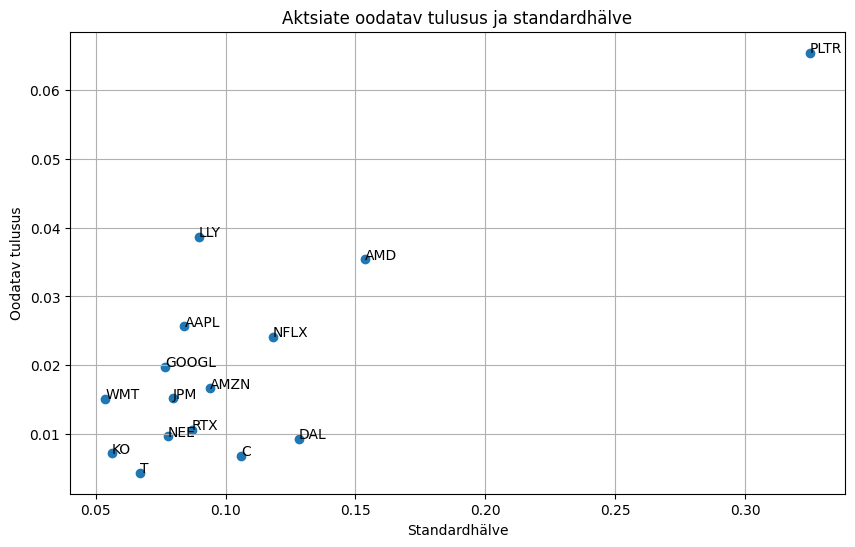

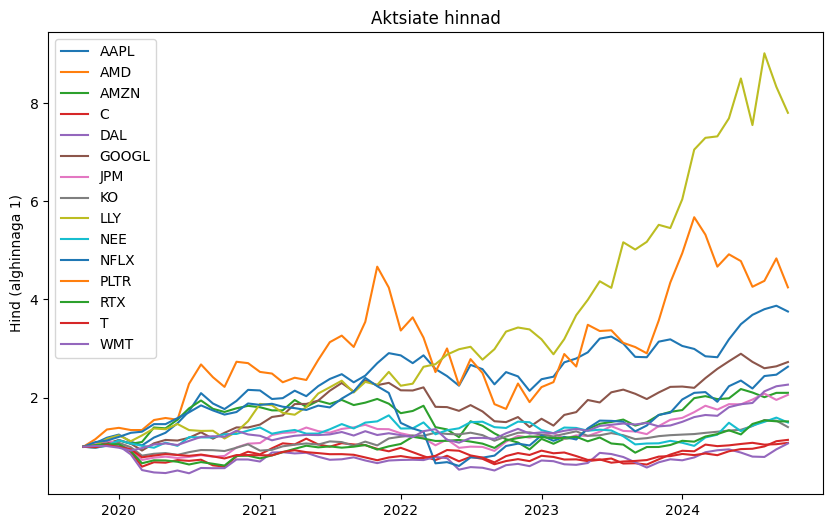

In [21]:
import matplotlib.pyplot as plt
import yfinance as yf
import numpy as np
import pandas as pd
from scipy import stats
from scipy.optimize import minimize


#a) Valige ülejäänud 10 aktsiat, mis kuuluvad portfelli.
#Apple, JPMorgan Chase, Alphabet, AT&T, Coca-Cola Company, lly, amzn, wmt, amd, rtx, dal, pltr, nflx, nee, c

#b) Koguge andmed kõikide aktsiate kohta perioodil oktoober 2019 kuni oktoober 2024. Andmete kogumiseks võib kasutada näiteks Pythoni paketti yfinance

aktsiad = ['AAPL', 'JPM', 'GOOGL', 'T', 'KO', 'LLY', 'AMZN', 'WMT', 'AMD', 'RTX', 'DAL', 'PLTR', 'NFLX', 'NEE', 'C']

andmed = yf.download(aktsiad, start='2019-10-01', end='2024-10-31', interval='1mo', auto_adjust=True) #saame kuised hinnad
andmed = andmed['Close'] #kõikidest andmetest jätame alles ainult sulgemishinnad

#c) Leidke aktsiate kuised tulusused, oodatavad tulusused ja tulususte standardhälbed perioodil oktoober 2019 kuni oktoober 2024.
tulusused = andmed.pct_change()
oodatavad = tulusused.mean()
st_halbed = tulusused.std()

#d) Esitage aktsiate oodatavad tulusused ja standardhälbed joonisel (x-teljel standardhälve, y-teljel oodatav tulusus) koos aktsiate nimedega.
plt.figure(figsize=(10,6))
plt.scatter(st_halbed, oodatavad)
for i, aktsia in enumerate(oodatavad.index):
    plt.annotate(aktsia, (st_halbed[i], oodatavad[i]))#kanname aktsiate tähised graafikule

plt.xlabel('Standardhälve')
plt.ylabel('Oodatav tulusus')
plt.title('Aktsiate oodatav tulusus ja standardhälve')
plt.grid(True)
plt.show()

#e) Esitage aktsiate hindade käitumine ühel graafikul, kus kõikide aktsiate alghinnaks (oktoober 2019) on võetud 1.
norm_hinnad = andmed/andmed.iloc[0] #jagades kõik hinnad alghinnaga, saame suhtelised muutused

plt.figure(figsize=(10,6))
for aktsia in norm_hinnad.columns:
    plt.plot(norm_hinnad.index, norm_hinnad[aktsia], label=aktsia)

plt.legend()
plt.title('Aktsiate hinnad')
plt.ylabel('Hind (alghinnaga 1)')
plt.show()



In [22]:
#f) Võimalikud anomaaliad andmetes
#varad millel on ekstreemsed z-skoorid(standardskoor) (z-skoorid > 3 või < -3)
def anomaaliad(andmed, tulusused, show_plots=True):
    report = {}
    z = tulusused.apply(lambda x: (x-x.mean())/x.std(), axis=0) #z-skoorid
    ekstreemne = z.abs() > 3
    ekstreemsed = {}
    for col in tulusused.columns:
        if ekstreemne[col].any():
            ekstreemsed[col] = tulusused[col][ekstreemne[col]].sort_values()
    report['ekstreemsed'] = ekstreemsed

    # volatiilsuse hüpped
    vol_hüpped = {}
    for col in tulusused.columns:
        vol = 3 * tulusused[col].std()
        hüpped = tulusused[col][tulusused[col].abs() > vol]
        if len(hüpped) > 0:
            vol_hüpped[col] = hüpped
    report['vol_hüpped'] = vol_hüpped

    #suurimad muutused hindades, kuu põhised
    muutused = {}
    for col in tulusused.columns:
        s = tulusused[col].dropna().sort_values()
        muutused[col] = {
            'suurimad_langused': s.head(5),
            'suurimad_tõusud': s.tail(5).sort_values(ascending=False)
        }
    report['muutused'] = muutused

    # vähe erinevaid hinnaväärtusi
    muutumatud_hinnad = []
    for col in andmed.columns:
        if andmed[col].dropna().nunique() <= 3: #kui unikaalsete hindade arv on 3 või vähem
            muutumatud_hinnad.append(col)
    report['muutumatud_hinnad'] = muutumatud_hinnad

    print(f"Varade arv, millel on z-skoori kõrvalekalduvused (>3 sigma): {len(report['ekstreemsed'])}")
    print(f"Varade arv, millel on volatiilsuse hüpped (>3*std): {len(report['vol_hüpped'])}")
    #print(f"Varad, millel on suurimad hinnamuutused kuu põhiselt: {(report['muutused'])}") #siin on palju infot, võib-olla liiga palju ja pole kindel kas siin anomaaliate all vajalik?
    if len(report['muutumatud_hinnad']) > 0:
        print("Varad, millel on väga vähe erinevaid hinnaväärtusi (võivad olla aegunud või mittelikviidsed):", report['muutumatud_hinnad']) # arvatavasti meie aktsiate puhul ei ole selliseid, võibolla mitte vajalik uurida praegu?

    return report

anom = anomaaliad(andmed, tulusused)


Varade arv, millel on z-skoori kõrvalekalduvused (>3 sigma): 8
Varade arv, millel on volatiilsuse hüpped (>3*std): 6


In [23]:
#Portfelli oodatav tulusus, risk ja Sharpe suhtarv, vaja et leida oodatav tulusus, g) 3) jaoks.
kov_maatriks = tulusused.cov()

def Portfelli_tulusus(kaalud):
    kaalud = np.array(kaalud)
    tulusus = np.sum(oodatavad * kaalud)
    return tulusus

def Portfelli_risk(kaalud):
    kaalud = np.array(kaalud)
    risk = np.sqrt(np.dot(kaalud.T, np.dot(kov_maatriks, kaalud)))
    return risk

def Portfelli_Sharpe(kaalud,rf_aasta):
    kaalud = np.array(kaalud)
    tulusus = np.sum(oodatavad * kaalud)
    risk = np.sqrt(np.dot(kaalud.T, np.dot(kov_maatriks, kaalud)))
    sharpe = (tulusus - rf_aasta/12)/risk
    return sharpe

kaalud = [(1/15),(1/15),(1/15),(1/15),(1/15),(1/15),(1/15),(1/15),(1/15),(1/15),(1/15),(1/15),(1/15),(1/15),(1/15)]
print('Portfelli oodatav tulusus: ', Portfelli_tulusus(kaalud))
print('Portfelli tulususte standardhälve: ', Portfelli_risk(kaalud))
print('Portfelli Sharpe suhtarv, rf_aasta = 0.03,: ', Portfelli_Sharpe(kaalud,0.03)) #pidime võtma hoopis 0.03 kuna rf_aasta on 3%

Portfelli oodatav tulusus:  0.020287888199577133
Portfelli tulususte standardhälve:  0.06283630451469079
Portfelli Sharpe suhtarv, rf_aasta = 0.03,:  0.2830829778574649


In [24]:
# g) 1) Riski minimiseerimine kui lühikeseks müümine ei ole lubatud

def kontroll_sum(kaalud):
    #Tagastab 0 kui kaalude summa 1
    return np.sum(kaalud)-1

piirid_1 = ([0,1],[0,1],[0,1],[0,1],[0,1],[0,1],[0,1],[0,1],[0,1],[0,1],[0,1],[0,1],[0,1],[0,1],[0,1])

kitsendus_1 = ({'type' : 'eq', 'fun':kontroll_sum})

kaalud = [(1/15),(1/15),(1/15),(1/15),(1/15),(1/15),(1/15),(1/15),(1/15),(1/15),(1/15),(1/15),(1/15),(1/15),(1/15)]

riskmin_1 = minimize(Portfelli_risk, kaalud,method='SLSQP', bounds=piirid_1, constraints=kitsendus_1)
print('RISKI MINIMISEERIMINE, KUI LÜHIKESEKS MÜÜMINE EI OLE LUBATUD')
print('Minimiseerimise tulemused: ',riskmin_1)
print(1*'\n')
print('Optimaalsed kaalud: {}'.format(riskmin_1.x))
print('Portfelli risk: ', round(riskmin_1.fun,5))
print('Portfelli tulusus: ', round(Portfelli_tulusus(riskmin_1.x),5))
print('Portfelli Sharpe: ', round(Portfelli_Sharpe(riskmin_1.x,0.03),5))
print(2*'\n')

RISKI MINIMISEERIMINE, KUI LÜHIKESEKS MÜÜMINE EI OLE LUBATUD
Minimiseerimise tulemused:       message: Optimization terminated successfully
     success: True
      status: 0
         fun: 0.03925982620119784
           x: [ 0.000e+00  1.624e-17 ...  2.102e-01  2.835e-01]
         nit: 11
         jac: [ 5.318e-02  5.725e-02 ...  3.947e-02  3.910e-02]
        nfev: 176
        njev: 11
 multipliers: [ 3.926e-02]


Optimaalsed kaalud: [0.00000000e+00 1.62359275e-17 7.93790801e-02 0.00000000e+00
 0.00000000e+00 2.59218632e-02 8.60508258e-03 1.88712153e-01
 1.02434052e-01 1.01231583e-01 0.00000000e+00 2.16637147e-17
 1.08284692e-17 2.10219140e-01 2.83497047e-01]
Portfelli risk:  0.03926
Portfelli tulusus:  0.01348
Portfelli Sharpe:  0.27974





In [25]:
def kontroll_sum(kaalud):
    #Tagastab 0 kui kaalude summa 1
    return np.sum(kaalud)-1

# Riski minimiseerimine kui lühikeseks müümine on lubatud, pole vaja tegelt kasutasin siit lihtsalt paari asja.

piirid_2 = ((None,None),(None,None),(None,None),(None,None),(None,None),(None,None),(None,None),(None,None),(None,None),(None,None),(None,None),(None,None),(None,None),(None,None),(None,None))

kaalud = [(1/15),(1/15),(1/15),(1/15),(1/15),(1/15),(1/15),(1/15),(1/15),(1/15),(1/15),(1/15),(1/15),(1/15),(1/15)]

riskmin_2 = minimize(Portfelli_risk, kaalud,method='SLSQP', bounds=piirid_2,constraints=kitsendus_1)
print('RISKI MINIMISEERIMINE, KUI LÜHIKESEKS MÜÜMINE ON LUBATUD')
print('Minimiseerimise tulemused: ',riskmin_2)
print(1*'\n')
print('Optimaalsed kaalud: {}'.format(riskmin_2.x))
print('Portfelli risk: ', round(riskmin_2.fun,5))
print('Portfelli tulusus: ', round(Portfelli_tulusus(riskmin_2.x),5))
print('Portfelli Sharpe: ', round(Portfelli_Sharpe(riskmin_2.x,0.03),5))

RISKI MINIMISEERIMINE, KUI LÜHIKESEKS MÜÜMINE ON LUBATUD
Minimiseerimise tulemused:       message: Optimization terminated successfully
     success: True
      status: 0
         fun: 0.03638058806952468
           x: [-1.720e-01 -3.873e-02 ...  2.462e-01  2.731e-01]
         nit: 25
         jac: [ 3.623e-02  3.634e-02 ...  3.620e-02  3.637e-02]
        nfev: 401
        njev: 25
 multipliers: [ 3.638e-02]


Optimaalsed kaalud: [-0.17197805 -0.03873389  0.27537537 -0.10337954 -0.00290965  0.01397607
  0.20526752  0.23602482  0.08855185  0.11501744 -0.05469303 -0.01496
 -0.06686022  0.24617342  0.2731279 ]
Portfelli risk:  0.03638
Portfelli tulusus:  0.0099
Portfelli Sharpe:  0.20338


In [26]:
# g) 2) Turuportfelli leidmine, kui lühikeseks müümine ei ole lubatud

def Neg_Sharpe(kaalud):
    return -Portfelli_Sharpe(kaalud, rf_aasta=0.03)

kaalud = [(1/15),(1/15),(1/15),(1/15),(1/15),(1/15),(1/15),(1/15),(1/15),(1/15),(1/15),(1/15),(1/15),(1/15),(1/15)]

riskmin_5 = minimize(Neg_Sharpe, kaalud,method='SLSQP', bounds=piirid_1,constraints=kitsendus_1)
print('TURUPORTFELLI LEIDMINE, KUI LÜHIKESEKS MÜÜMINE EI OLE LUBATUD')
print('Minimiseerimise tulemused: ',riskmin_5)
print(1*'\n')
print('Optimaalsed kaalud: {}'.format(riskmin_5.x))
print('Portfelli risk: ', round(Portfelli_risk(riskmin_5.x),5))
print('Portfelli tulusus: ', round(Portfelli_tulusus(riskmin_5.x),5))
print('Portfelli Sharpe: ', round(Portfelli_Sharpe(riskmin_5.x,0.03),5))

TURUPORTFELLI LEIDMINE, KUI LÜHIKESEKS MÜÜMINE EI OLE LUBATUD
Minimiseerimise tulemused:       message: Optimization terminated successfully
     success: True
      status: 0
         fun: -0.4694447504294094
           x: [ 1.258e-01  6.703e-02 ...  1.594e-17  1.867e-01]
         nit: 9
         jac: [-4.350e-02 -4.342e-02 ...  3.220e-02 -4.363e-02]
        nfev: 145
        njev: 9
 multipliers: [-4.360e-02]


Optimaalsed kaalud: [1.25775252e-01 6.70272017e-02 5.32343267e-17 0.00000000e+00
 5.74627151e-18 8.57287708e-02 5.81409068e-02 0.00000000e+00
 4.76603371e-01 0.00000000e+00 0.00000000e+00 2.16840434e-19
 8.78203760e-18 1.59377719e-17 1.86724498e-01]
Portfelli risk:  0.05738
Portfelli tulusus:  0.02944
Portfelli Sharpe:  0.46944


In [27]:
# g) 3) Portfelli oodatav tulusus on võrdne võrdsete kaaludega moodustatud portfelli oodatava tulususega ning lühikeseks müümine ei ole lubatud
kitsendus_3 = ({'type':'eq', 'fun':kontroll_sum},
            {'type':'eq', 'fun': lambda w: Portfelli_tulusus(w) - 0.02028788873446832})
kaalud = [(1/15),(1/15),(1/15),(1/15),(1/15),(1/15),(1/15),(1/15),(1/15),(1/15),(1/15),(1/15),(1/15),(1/15),(1/15)]

riskmin_4 = minimize(Portfelli_risk,kaalud,method='SLSQP', bounds=piirid_1, constraints=kitsendus_3)
print('RISKI MINIMISEERIMINE ETTEANTUD TULUSUSE KORRAL, KUI LÜHIKESEKS MÜÜMINE EI OLE LUBATUD')
print('Minimiseerimise tulemused: ',riskmin_4)
print(1*'\n')
print('Optimaalsed kaalud: {}'.format(riskmin_4.x))
print('Portfelli risk: ', round(riskmin_4.fun,5))
print('Portfelli tulusus: ', round(Portfelli_tulusus(riskmin_4.x),5))
print('Portfelli Sharpe: ', round(Portfelli_Sharpe(riskmin_4.x,0.03),5))

RISKI MINIMISEERIMINE ETTEANTUD TULUSUSE KORRAL, KUI LÜHIKESEKS MÜÜMINE EI OLE LUBATUD
Minimiseerimise tulemused:       message: Optimization terminated successfully
     success: True
      status: 0
         fun: 0.0430818009721267
           x: [ 1.383e-02  1.289e-02 ...  8.469e-02  3.244e-01]
         nit: 14
         jac: [ 4.856e-02  5.825e-02 ...  2.626e-02  3.766e-02]
        nfev: 225
        njev: 14
 multipliers: [ 2.177e-02  1.050e+00]


Optimaalsed kaalud: [1.38320324e-02 1.28872830e-02 8.13151629e-20 0.00000000e+00
 0.00000000e+00 1.25359938e-01 6.10393276e-02 7.29497459e-02
 2.52184743e-01 5.26703770e-02 1.62630326e-18 0.00000000e+00
 0.00000000e+00 8.46901664e-02 3.24386386e-01]
Portfelli risk:  0.04308
Portfelli tulusus:  0.02029
Portfelli Sharpe:  0.41289


In [28]:
# g) 4) Turuportfelli leidmine, kui lühikeseks müümine on lubatud osaliselt
from scipy.optimize import NonlinearConstraint

x = 0.4   # meie parameeter, rühm 7

def abs_constraint(kaalud):
    return np.sum(np.abs(kaalud))

# Tingimus: sum(|w_i|) <= 1 + 2x
nlc = NonlinearConstraint(abs_constraint, -np.inf, 1 + 2*x)

lin_constraint = {'type':'eq','fun': kontroll_sum}

# Lühikeseks müümine osaliselt lubatud
piirid_3 = [(-1, 1), (-1, 1), (-1, 1), (-1, 1), (-1, 1), (-1, 1), (-1, 1), (-1, 1), (-1, 1), (-1, 1), (-1, 1), (-1, 1), (-1, 1), (-1, 1), (-1, 1)]

riskmin_6 = minimize(Neg_Sharpe, kaalud, method='SLSQP', bounds=piirid_3, constraints=[lin_constraint, nlc])

print("Optimaalsed kaalud:", riskmin_6.x)
print("Risk:", Portfelli_risk(riskmin_6.x))
print("Tulusus:", Portfelli_tulusus(riskmin_6.x))
print("Sharpe:", Portfelli_Sharpe(riskmin_6.x, 0.03))

Optimaalsed kaalud: [ 2.33727825e-01  8.84759741e-02 -1.67099293e-01 -1.37239066e-01
 -5.78492703e-08  1.97297870e-01  1.58604141e-01 -5.17822155e-02
  4.60222501e-01 -3.47291588e-02 -4.62709458e-04 -2.85092914e-06
  4.57146158e-02 -8.68471751e-03  2.15957140e-01]
Risk: 0.05939757526914082
Tulusus: 0.03251524615258927
Sharpe: 0.5053278019613584


In [29]:
# h) Tabel punktis g leitud portfellide (ja võrdselt kaalutud portfelli) kohta

tulusused_ilma_NaN = andmed.pct_change().dropna()  # kuised tootlused treeningperioodil

rf_aasta = 0.03 # riskivaba määr aastas
rf_kuu = rf_aasta / 12 # ning kuus


portfellid_h = { # portfellid eelmisest punktist)
    "Minimaalne risk (lühikeseks müümiseta)":  riskmin_1.x,
    "Minimaalne risk (lühikeseks müümisega)":  riskmin_2.x,
    "Turuportfell (lühikeseks müümiseta)":     riskmin_5.x,
    "Turuportfell (osaline lühikeseks müümine)": riskmin_6.x,
}


def portfelli_naitajad(kaalud):
    w = np.array(kaalud)
    portf_tulusused = tulusused_ilma_NaN.values @ w
    mu = portf_tulusused.mean()          # oodatav kuutootlus
    std = portf_tulusused.std(ddof=1)    # risk ehk standardhälve
    sharpe = (mu - rf_kuu) / std         # Sharpe'i suhtarv
    return mu, std, sharpe

# võrdsete kaalude lisamine portfelli
kaalud_vordsed = np.array([1/15] * 15)
portfellid_h["Vordsed_kaalud"] = kaalud_vordsed

read_h = [] # tabel tulemuste jaoks
for nimi, w in portfellid_h.items():
    mu, std, sharpe = portfelli_naitajad(w)
    read_h.append([mu, std, sharpe])

tabel_h = pd.DataFrame(
    read_h,
    index=portfellid_h.keys(),
    columns=["Oodatav tulusus (kuu)", "Risk (std, kuu)", "Sharpe"]
)

tabel_h



,Oodatav tulusus (kuu),"Risk (std, kuu)",Sharpe
Minimaalne risk (lühikeseks müümiseta),0.014137,0.038790,0.300010
Minimaalne risk (lühikeseks müümisega),0.011144,0.036010,0.240045
Turuportfell (lühikeseks müümiseta),0.028843,0.058652,0.449140
Turuportfell (osaline lühikeseks müümine),0.032074,0.061131,0.483771
Vordsed_kaalud,0.020710,0.060770,0.299649


In [31]:
# i) 
import yfinance as yf

# a) Koguge andmed kõikide aktsiate kohta perioodil november 2024 kuni märts 2025
andmed2 = yf.download(aktsiad, start='2024-11-01',end='2025-03-31',interval='1mo',auto_adjust=True)
andmed2 = andmed2['Close']
tulusused2 = andmed2.pct_change().dropna()

# b) Leike aktsiate kuised tulusused, oodatavad tulusused ja tulususte standardhälbed perioodil november 2024 kuni märts 2025.
def portfelli_naitajad2(kaalud):
    kaalud = np.array(kaalud)
    portf_tulusused = tulusused2.values @ kaalud
    mu = portf_tulusused.mean() # oodatav tootlus antud perioodil
    std = portf_tulusused.std(ddof=1) # perioodi standardhälve
    riskipreemia = (mu - rf_kuu) / std # riskipreemia
    return mu, std, riskipreemia

# c)  Esitage nelja optimaalsete kaaludega portfelli (moodustatud punktis g)) ning lisaks võrdsete kaaludega portfelli jaoks ühes tabelis oodatav tulusus, risk (standardhälve) ning Sharpe’i suhtarv viie kuu (november 2024 kuni märts 2025) andmete põhjal.
read_i = []
for nimi, w in portfellid_h.items():
    mu, sigma, sharpe = portfelli_naitajad2(w)
    read_i.append([mu, sigma, sharpe])

tabel_i = pd.DataFrame(
    read_i,
    index=portfellid_h.keys(),
    columns=["Oodatav tulusus (kuu)", "Risk (std, kuu)", "Sharpe"]
)

tabel_i



[*********************100%***********************]  15 of 15 completed


,Oodatav tulusus (kuu),"Risk (std, kuu)",Sharpe
Minimaalne risk (lühikeseks müümiseta),0.012550,0.050943,0.197275
Minimaalne risk (lühikeseks müümisega),0.013227,0.056238,0.190739
Turuportfell (lühikeseks müümiseta),-0.002691,0.063157,-0.082185
Turuportfell (osaline lühikeseks müümine),-0.006298,0.055988,-0.157145
Vordsed_kaalud,-0.001001,0.050622,-0.069163
